In [1]:
from ultralytics import YOLO

model = YOLO(
    "../runs/detect/results/yolo/retail_yolo11n/weights/best.pt"
)

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [2]:
from pathlib import Path

cropped_dir = Path("../data/processed/cropped_products")

cropped_dir.mkdir(parents=True, exist_ok=True)

print("Crop output directory created:")
print(cropped_dir)

Crop output directory created:
..\data\processed\cropped_products


In [3]:
from pathlib import Path
import xml.etree.ElementTree as ET

xml_dir = Path("../data/raw/annotations/train")
image_dir = Path("../data/raw/images/train")

xml_files = list(xml_dir.glob("*.xml"))

print("XML files:", len(xml_files))
print("Images:", len(list(image_dir.glob("*"))))

XML files: 294
Images: 294


In [4]:
sample_xml = xml_files[0]

tree = ET.parse(sample_xml)
root = tree.getroot()

print("File:", sample_xml.name)

for obj in root.findall("object"):
    class_name = obj.find("name").text

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print("Class:", class_name)
    print("Bounding box:", xmin, ymin, xmax, ymax)

File: aqua (1).xml
Class: aqua
Bounding box: 211 122 297 356


In [5]:
classes = [
    "aqua",
    "chitato",
    "indomie",
    "pepsodent",
    "shampoo",
    "tissue"
]

for class_name in classes:
    (cropped_dir / class_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("Class folders created:")
for class_name in classes:
    print(f"✓ {class_name}")

Class folders created:
✓ aqua
✓ chitato
✓ indomie
✓ pepsodent
✓ shampoo
✓ tissue


In [6]:
image_files = list(image_dir.glob("*"))

print("Total image files:", len(image_files))

for image_file in image_files[:10]:
    print(image_file.name)

Total image files: 294
aqua (1).jpg
aqua (10).jpg
aqua (11).jpg
aqua (12).jpg
aqua (13).jpg
aqua (14).jpg
aqua (15).jpg
aqua (16).jpg
aqua (17).jpg
aqua (18).jpg


In [7]:
from PIL import Image

cropped_count = 0
skipped_count = 0

for xml_file in xml_files:

    # Find the corresponding image using the XML filename stem
    image_file = image_dir / f"{xml_file.stem}.jpg"

    if not image_file.exists():
        print(f"Image not found: {image_file.name}")
        skipped_count += 1
        continue

    # Read XML
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Open image
    image = Image.open(image_file)

    # Process every object in the annotation
    for object_index, obj in enumerate(root.findall("object")):

        class_name = obj.find("name").text.strip()

        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        # Crop the product
        crop = image.crop((xmin, ymin, xmax, ymax))

        # Create a unique filename
        crop_filename = (
            f"{xml_file.stem}_object_{object_index + 1}.jpg"
        )

        crop_path = cropped_dir / class_name / crop_filename

        # Save crop
        crop.save(crop_path)

        cropped_count += 1

print(f"Products cropped: {cropped_count}")
print(f"Skipped images: {skipped_count}")

Products cropped: 579
Skipped images: 0


In [8]:
for class_name in classes:
    class_dir = cropped_dir / class_name
    count = len(list(class_dir.glob("*.jpg")))
    print(f"{class_name}: {count}")

aqua: 97
chitato: 97
indomie: 95
pepsodent: 97
shampoo: 96
tissue: 97


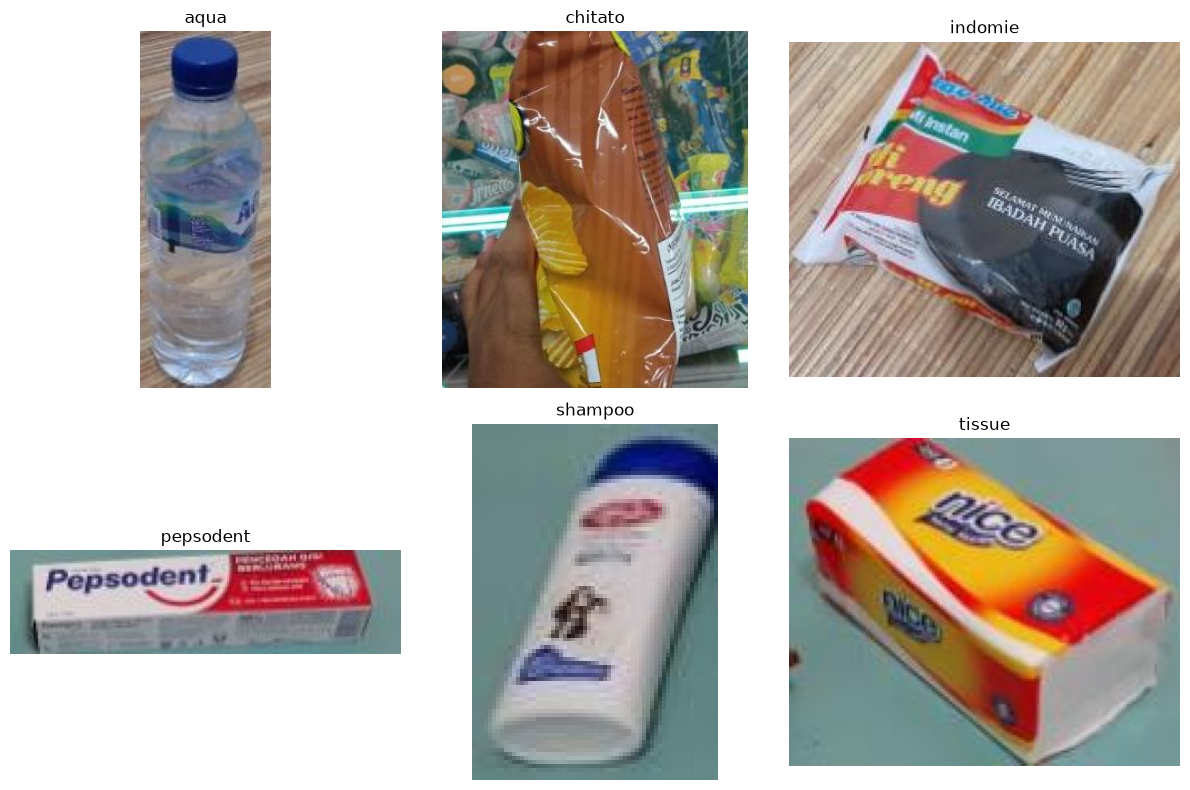

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, class_name in zip(axes.flatten(), classes):

    class_dir = cropped_dir / class_name
    sample_file = next(class_dir.glob("*.jpg"))

    image = Image.open(sample_file)

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()